In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 150)

# Load data
train = pd.read_csv("../data/train-test.csv")
validation = pd.read_csv("../data/validation.csv")

print(f"Training Shape: {train.shape}")
print(f"Validation Shape: {validation.shape}")


train.head()

Training Shape: (48000, 14)
Validation Shape: (12000, 13)


,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,2025-01-01,0.94518,1.87712,1827.28
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,2025-01-01,0.98480,2.56300,1380.28


In [2]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48000 entries, 0 to 47999
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   load_id       48000 non-null  object 
 1   pickup        48000 non-null  object 
 2   delivery      48000 non-null  object 
 3   pickup_lat    48000 non-null  float64
 4   pickup_lon    48000 non-null  float64
 5   delivery_lat  48000 non-null  float64
 6   delivery_lon  48000 non-null  float64
 7   distance      48000 non-null  float64
 8   equipment     48000 non-null  object 
 9   weight        47700 non-null  float64
 10  date          48000 non-null  object 
 11  market_index  47626 non-null  float64
 12  quote_signal  48000 non-null  float64
 13  posted_rate   48000 non-null  float64
dtypes: float64(9), object(5)
memory usage: 5.1+ MB


In [3]:
train.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
load_id,48000,48000,TR-000001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pickup,48000,64,Oklahoma City,1242,NaN,NaN,NaN,NaN,NaN,NaN,NaN
delivery,48000,64,Lexington,1197,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pickup_lat,48000.0,NaN,NaN,NaN,35.647545,4.315285,28.35765,31.98691,35.29479,39.41104,44.30296
pickup_lon,48000.0,NaN,NaN,NaN,-90.928964,13.482431,-121.69849,-98.40059,-88.08915,-83.28506,-69.5
delivery_lat,48000.0,NaN,NaN,NaN,35.641175,4.317199,28.35765,31.98691,35.29479,39.41104,44.30296
delivery_lon,48000.0,NaN,NaN,NaN,-90.85731,13.476589,-121.69849,-98.40059,-87.52871,-83.28506,-69.5
distance,48000.0,NaN,NaN,NaN,1135.856654,728.564416,70.0,550.4,953.3,1645.525,3439.8
equipment,48000,3,Dry Van,27202,NaN,NaN,NaN,NaN,NaN,NaN,NaN
weight,47700.0,NaN,NaN,NaN,31028.844004,9391.44062,-47500.0,25800.0,31436.5,37018.0,47500.0


In [4]:
missing = train.isnull().sum().sort_values(ascending=False)

missing = missing[missing > 0]

missing

market_index    374
weight          300
dtype: int64

In [5]:
train.duplicated().sum()

np.int64(0)

In [6]:
train["posted_rate"].describe()

count    48000.000000
mean      2373.980682
std       1486.493245
min         57.220000
25%       1251.555000
50%       2030.760000
75%       3330.750000
max      25533.000000
Name: posted_rate, dtype: float64

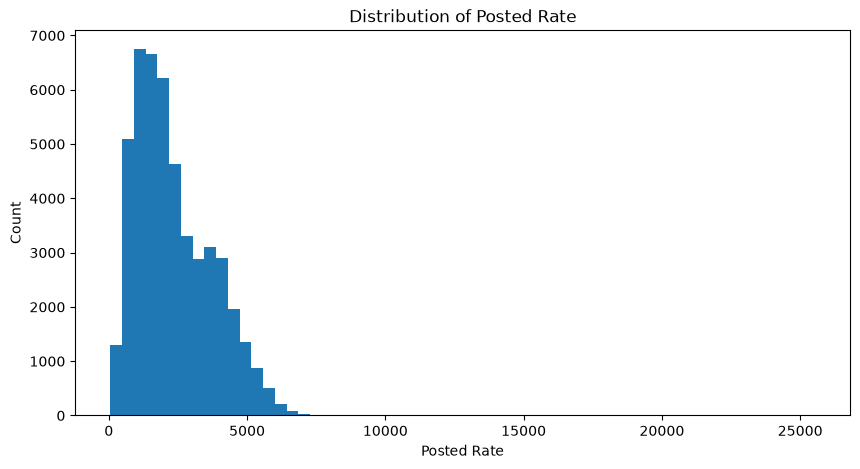

In [7]:
plt.figure(figsize=(10,5))

plt.hist(train["posted_rate"], bins=60)

plt.title("Distribution of Posted Rate")

plt.xlabel("Posted Rate")

plt.ylabel("Count")

plt.show()

In [8]:
corr = train.select_dtypes("number").corr()

corr["posted_rate"].sort_values(ascending=False)

posted_rate     1.000000
distance        0.908519
weight          0.034840
market_index    0.034165
quote_signal   -0.039858
pickup_lat     -0.090873
delivery_lat   -0.091970
pickup_lon     -0.255058
delivery_lon   -0.257086
Name: posted_rate, dtype: float64

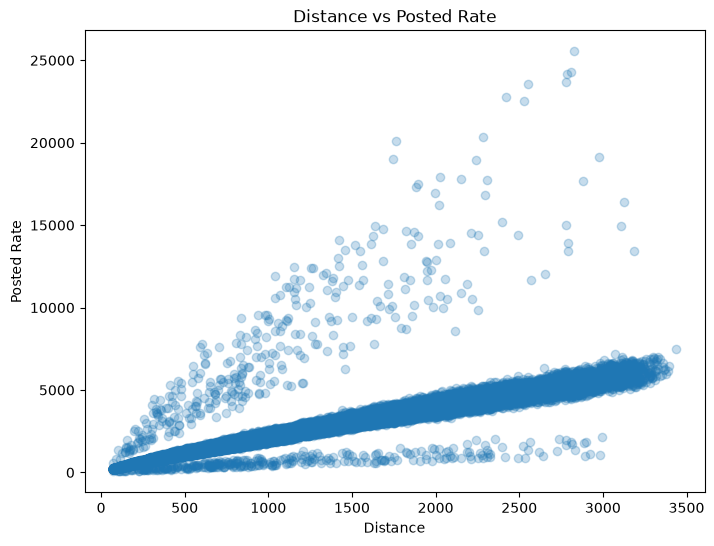

In [9]:
plt.figure(figsize=(8,6))

plt.scatter(
    train["distance"],
    train["posted_rate"],
    alpha=0.25
)

plt.xlabel("Distance")

plt.ylabel("Posted Rate")

plt.title("Distance vs Posted Rate")

plt.show()

In [10]:
train["equipment"].value_counts()

equipment
Dry Van    27202
Reefer     12045
Flatbed     8753
Name: count, dtype: int64

In [11]:
train["date"] = pd.to_datetime(train["date"])

validation["date"] = pd.to_datetime(validation["date"])

In [12]:
for df in [train, validation]:

    df["year"] = df["date"].dt.year
    df["month"] = df["date"].dt.month
    df["day"] = df["date"].dt.day
    df["weekday"] = df["date"].dt.dayofweek
    df["week"] = df["date"].dt.isocalendar().week.astype(int)
    df["is_weekend"] = (df["weekday"] >= 5).astype(int)

In [13]:
train.head()

,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate,year,month,day,weekday,week,is_weekend
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41,2025,1,1,2,1,0
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97,2025,1,1,2,1,0
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54,2025,1,1,2,1,0
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,2025-01-01,0.94518,1.87712,1827.28,2025,1,1,2,1,0
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,2025-01-01,0.98480,2.56300,1380.28,2025,1,1,2,1,0


In [15]:
corr = train.select_dtypes(include="number").corr()

corr["posted_rate"].sort_values(ascending=False)

posted_rate     1.000000
distance        0.908519
weight          0.034840
market_index    0.034165
week            0.024562
month           0.023804
day             0.010305
weekday        -0.003383
is_weekend     -0.008299
quote_signal   -0.039858
pickup_lat     -0.090873
delivery_lat   -0.091970
pickup_lon     -0.255058
delivery_lon   -0.257086
year                 NaN
Name: posted_rate, dtype: float64

In [16]:
train.groupby("equipment")["posted_rate"].agg(["count", "mean", "median", "std"])

,count,mean,median,std
equipment,,,,
Dry Van,27202,2271.548686,1953.035,1423.029914
Flatbed,8753,2445.087223,2076.810,1505.053087
Reefer,12045,2553.636939,2196.670,1589.670824


In [17]:
train["pickup"].value_counts().head(20)

pickup
Oklahoma City    1242
Lexington        1209
Bakersfield      1193
Fort Wayne       1170
Hartford         1150
Richmond         1140
Nashville        1124
Phoenix          1121
Baton Rouge      1115
Mobile           1094
Cincinnati       1080
Shreveport       1062
Kansas City      1053
Columbia         1049
Atlanta          1029
San Antonio       972
Philadelphia      946
Los Angeles       945
Milwaukee         944
Tucson            944
Name: count, dtype: int64

In [18]:
train["delivery"].value_counts().head(20)

delivery
Lexington        1197
Fort Wayne       1176
Baton Rouge      1167
Bakersfield      1156
Hartford         1143
Oklahoma City    1140
Richmond         1109
Atlanta          1096
Phoenix          1090
Mobile           1089
Cincinnati       1084
Columbia         1071
Nashville        1064
Tucson            997
Shreveport        983
Kansas City       980
San Antonio       965
Philadelphia      959
Los Angeles       955
Syracuse          926
Name: count, dtype: int64

In [19]:
train["route"] = train["pickup"] + " -> " + train["delivery"]
validation["route"] = validation["pickup"] + " -> " + validation["delivery"]

In [20]:
train["route"].value_counts().head(20)

route
Columbia -> Oklahoma City     39
Phoenix -> Shreveport         39
Lexington -> Atlanta          39
Fort Wayne -> Philadelphia    38
Shreveport -> Hartford        37
Lexington -> Cincinnati       37
Fort Wayne -> Hartford        37
Richmond -> Phoenix           37
Richmond -> Oklahoma City     37
Lexington -> Kansas City      37
Mobile -> Phoenix             36
Fort Wayne -> Cincinnati      36
Syracuse -> Mobile            35
Nashville -> Baton Rouge      35
Columbia -> Montgomery        35
Oklahoma City -> Columbia     35
Richmond -> Cincinnati        35
Philadelphia -> Lexington     35
Hartford -> Baton Rouge       35
Oklahoma City -> Nashville    35
Name: count, dtype: int64

In [21]:
train.groupby("route")["posted_rate"].mean().sort_values(ascending=False).head(20)

route
Tucson -> Raleigh              7184.458750
Baltimore -> Reno              7061.231429
Phoenix -> Baltimore           7026.094286
Dallas -> Grand Rapids         6943.305000
Providence -> Phoenix          6859.190833
Boston -> Bakersfield          6737.905000
San Francisco -> Boston        6571.740000
Reno -> Philadelphia           6555.731333
San Francisco -> Providence    6437.206000
Boston -> Phoenix              6420.760667
Boston -> Fresno               6389.587000
Los Angeles -> Syracuse        6374.636667
Boston -> San Francisco        6266.332857
Providence -> San Francisco    6253.057500
Boston -> Los Angeles          6215.110000
Los Angeles -> Providence      6192.038000
Fresno -> Boston               6160.404000
Providence -> Fresno           6144.510000
Montgomery -> Fresno           6095.699091
Providence -> Bakersfield      6090.151875
Name: posted_rate, dtype: float64

In [22]:
train["weight"] = train["weight"].fillna(train["weight"].median())
validation["weight"] = validation["weight"].fillna(train["weight"].median())

train["market_index"] = train["market_index"].fillna(train["market_index"].median())
validation["market_index"] = validation["market_index"].fillna(train["market_index"].median())

In [23]:
train.isnull().sum()

load_id         0
pickup          0
delivery        0
pickup_lat      0
pickup_lon      0
delivery_lat    0
delivery_lon    0
distance        0
equipment       0
weight          0
date            0
market_index    0
quote_signal    0
posted_rate     0
year            0
month           0
day             0
weekday         0
week            0
is_weekend      0
route           0
dtype: int64

In [24]:
equipment_summary = (
    train.groupby("equipment")["posted_rate"]
    .agg(["count", "mean", "median", "std"])
    .sort_values("mean", ascending=False)
)

equipment_summary

,count,mean,median,std
equipment,,,,
Reefer,12045,2553.636939,2196.670,1589.670824
Flatbed,8753,2445.087223,2076.810,1505.053087
Dry Van,27202,2271.548686,1953.035,1423.029914


In [25]:
train["pickup"].value_counts().head(20)

pickup
Oklahoma City    1242
Lexington        1209
Bakersfield      1193
Fort Wayne       1170
Hartford         1150
Richmond         1140
Nashville        1124
Phoenix          1121
Baton Rouge      1115
Mobile           1094
Cincinnati       1080
Shreveport       1062
Kansas City      1053
Columbia         1049
Atlanta          1029
San Antonio       972
Philadelphia      946
Los Angeles       945
Milwaukee         944
Tucson            944
Name: count, dtype: int64

In [26]:
train["delivery"].value_counts().head(20)

delivery
Lexington        1197
Fort Wayne       1176
Baton Rouge      1167
Bakersfield      1156
Hartford         1143
Oklahoma City    1140
Richmond         1109
Atlanta          1096
Phoenix          1090
Mobile           1089
Cincinnati       1084
Columbia         1071
Nashville        1064
Tucson            997
Shreveport        983
Kansas City       980
San Antonio       965
Philadelphia      959
Los Angeles       955
Syracuse          926
Name: count, dtype: int64

In [28]:
train["route"] = train["pickup"] + " -> " + train["delivery"]

validation["route"] = validation["pickup"] + " -> " + validation["delivery"]

In [29]:
train["route"].value_counts().head(20)

route
Columbia -> Oklahoma City     39
Phoenix -> Shreveport         39
Lexington -> Atlanta          39
Fort Wayne -> Philadelphia    38
Shreveport -> Hartford        37
Lexington -> Cincinnati       37
Fort Wayne -> Hartford        37
Richmond -> Phoenix           37
Richmond -> Oklahoma City     37
Lexington -> Kansas City      37
Mobile -> Phoenix             36
Fort Wayne -> Cincinnati      36
Syracuse -> Mobile            35
Nashville -> Baton Rouge      35
Columbia -> Montgomery        35
Oklahoma City -> Columbia     35
Richmond -> Cincinnati        35
Philadelphia -> Lexington     35
Hartford -> Baton Rouge       35
Oklahoma City -> Nashville    35
Name: count, dtype: int64

In [30]:
train.groupby("route")["posted_rate"] \
    .mean() \
    .sort_values(ascending=False) \
    .head(20)

route
Tucson -> Raleigh              7184.458750
Baltimore -> Reno              7061.231429
Phoenix -> Baltimore           7026.094286
Dallas -> Grand Rapids         6943.305000
Providence -> Phoenix          6859.190833
Boston -> Bakersfield          6737.905000
San Francisco -> Boston        6571.740000
Reno -> Philadelphia           6555.731333
San Francisco -> Providence    6437.206000
Boston -> Phoenix              6420.760667
Boston -> Fresno               6389.587000
Los Angeles -> Syracuse        6374.636667
Boston -> San Francisco        6266.332857
Providence -> San Francisco    6253.057500
Boston -> Los Angeles          6215.110000
Los Angeles -> Providence      6192.038000
Fresno -> Boston               6160.404000
Providence -> Fresno           6144.510000
Montgomery -> Fresno           6095.699091
Providence -> Bakersfield      6090.151875
Name: posted_rate, dtype: float64

In [31]:
weight_median = train["weight"].median()

market_index_median = train["market_index"].median()

train["weight"] = train["weight"].fillna(weight_median)
validation["weight"] = validation["weight"].fillna(weight_median)

train["market_index"] = train["market_index"].fillna(market_index_median)
validation["market_index"] = validation["market_index"].fillna(market_index_median)

In [32]:
train.isnull().sum()

load_id         0
pickup          0
delivery        0
pickup_lat      0
pickup_lon      0
delivery_lat    0
delivery_lon    0
distance        0
equipment       0
weight          0
date            0
market_index    0
quote_signal    0
posted_rate     0
year            0
month           0
day             0
weekday         0
week            0
is_weekend      0
route           0
dtype: int64

In [33]:
train.to_csv("../data/train_clean.csv", index=False)

validation.to_csv("../data/validation_clean.csv", index=False)

In [ ]:
corr = train.select_dtypes(include="number").corr()

corr["posted_rate"].sort_values(ascending=False)